# Welcome to Colab!

EXPERIMENT 1

Earliest start times: {'A': 0, 'B': 3, 'C': 3, 'D': 5, 'E': 7, 'F': 10}
Earliest finish times: {'A': 3, 'B': 5, 'C': 7, 'D': 7, 'E': 10, 'F': 11}
Latest start times: {'A': 0, 'B': 3, 'C': 3, 'D': 5, 'E': 7, 'F': 10}
Latest finish times: {'A': 3, 'B': 5, 'C': 7, 'D': 7, 'E': 10, 'F': 11}
Critical path: ['A', 'B', 'C', 'D', 'E', 'F']


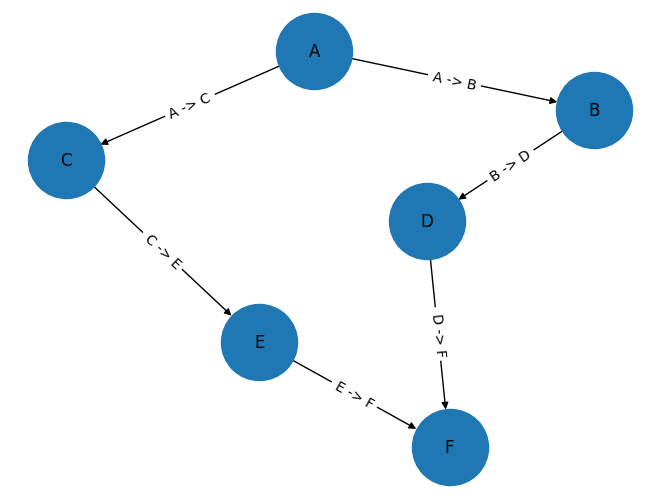

In [22]:
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt

tasks = {
    'A': {'duration': 3, 'dependencies': []},
    'B': {'duration': 2, 'dependencies': ['A']},
    'C': {'duration': 4, 'dependencies': ['A']},
    'D': {'duration': 2, 'dependencies': ['B']},
    'E': {'duration': 3, 'dependencies': ['C']},
    'F': {'duration': 1, 'dependencies': ['D', 'E']}
}

G = nx.DiGraph()

for task, data in tasks.items():
    G.add_node(task, duration=data['duration'])
    for dep in data['dependencies']:
        G.add_edge(dep, task)

topological_order = list(nx.topological_sort(G))

earliest_start = {task: 0 for task in topological_order}
earliest_finish = {task: 0 for task in topological_order}

for task in topological_order:
    earliest_finish[task] = earliest_start[task] + G.nodes[task]['duration']
    for successor in G.successors(task):
        earliest_start[successor] = max(
            earliest_start[successor],
            earliest_finish[task]
        )

latest_finish = {task: earliest_finish[task] for task in topological_order}
latest_start = {task: earliest_start[task] for task in topological_order}

for task in reversed(topological_order):
    for predecessor in G.predecessors(task):
        latest_finish[predecessor] = min(
            latest_finish[predecessor],
            latest_start[task]
        )
        latest_start[predecessor] = latest_finish[predecessor] - \
            G.nodes[predecessor]['duration']

critical_path = [
    task for task in topological_order
    if earliest_start[task] == latest_start[task]
]

print("Earliest start times:", earliest_start)
print("Earliest finish times:", earliest_finish)
print("Latest start times:", latest_start)
print("Latest finish times:", latest_finish)
print("Critical path:", critical_path)

pos = nx.spring_layout(G)
nx.draw(G, pos, with_labels=True, node_size=3000)

nx.draw_networkx_edge_labels(
    G,
    pos,
    edge_labels={(u, v): f"{u} -> {v}" for u, v in G.edges}
)

plt.show()

EXPERIMENT 2

Critical Path: ['A', 'B', 'C', 'D', 'E', 'F', 'G', 'H', 'I']


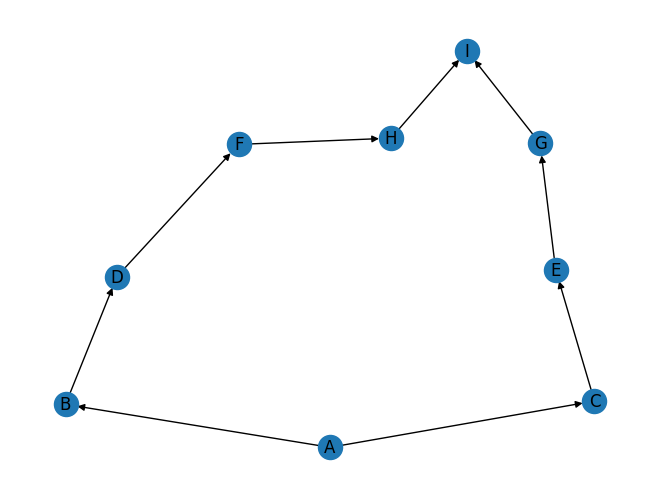

In [23]:
import networkx as nx
import matplotlib.pyplot as plt

tasks = {
    'A': {'duration': 3, 'dependencies': []},
    'B': {'duration': 2, 'dependencies': ['A']},
    'C': {'duration': 5, 'dependencies': ['A']},
    'D': {'duration': 4, 'dependencies': ['B']},
    'E': {'duration': 3, 'dependencies': ['C']},
    'F': {'duration': 2, 'dependencies': ['D']},
    'G': {'duration': 6, 'dependencies': ['E']},
    'H': {'duration': 3, 'dependencies': ['F']},
    'I': {'duration': 4, 'dependencies': ['G', 'H']}
}

G = nx.DiGraph()
for t, d in tasks.items():
    G.add_node(t, duration=d['duration'])
    for dep in d['dependencies']:
        G.add_edge(dep, t)

order = list(nx.topological_sort(G))
ES = {t: 0 for t in order}
EF = {t: 0 for t in order}

for t in order:
    EF[t] = ES[t] + G.nodes[t]['duration']
    for s in G.successors(t):
        ES[s] = max(ES[s], EF[t])

LS = ES.copy()
LF = EF.copy()

for t in reversed(order):
    for p in G.predecessors(t):
        LF[p] = min(LF[p], LS[t])
        LS[p] = LF[p] - G.nodes[p]['duration']

CP = [t for t in order if ES[t] == LS[t]]

print("Critical Path:", CP)
nx.draw(G, nx.spring_layout(G), with_labels=True)
plt.show()

EXPERIMENT 3

Critical Path: ['A', 'B', 'C', 'D', 'E', 'F', 'G', 'H', 'I']


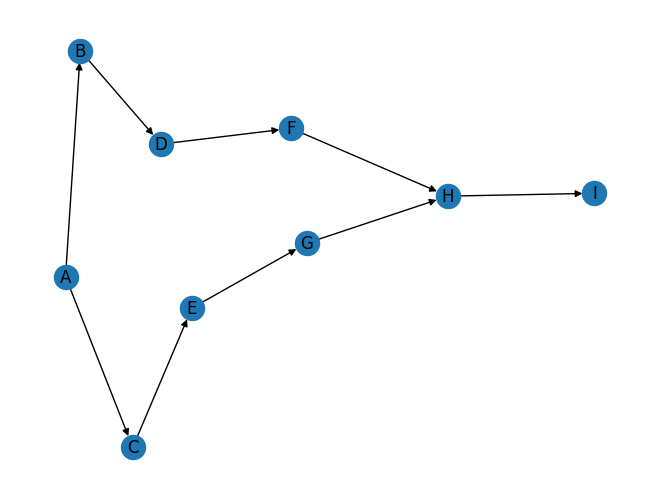

In [24]:
import networkx as nx
import matplotlib.pyplot as plt

tasks = {
    'A': {'duration': 2, 'dependencies': []},
    'B': {'duration': 4, 'dependencies': ['A']},
    'C': {'duration': 3, 'dependencies': ['A']},
    'D': {'duration': 5, 'dependencies': ['B']},
    'E': {'duration': 2, 'dependencies': ['C']},
    'F': {'duration': 4, 'dependencies': ['D']},
    'G': {'duration': 3, 'dependencies': ['E']},
    'H': {'duration': 2, 'dependencies': ['F', 'G']},
    'I': {'duration': 5, 'dependencies': ['H']}
}

# same logic as above
G = nx.DiGraph()
for t, d in tasks.items():
    G.add_node(t, duration=d['duration'])
    for dep in d['dependencies']:
        G.add_edge(dep, t)

order = list(nx.topological_sort(G))
ES, EF = {t: 0 for t in order}, {t: 0 for t in order}

for t in order:
    EF[t] = ES[t] + G.nodes[t]['duration']
    for s in G.successors(t):
        ES[s] = max(ES[s], EF[t])

LS, LF = ES.copy(), EF.copy()

for t in reversed(order):
    for p in G.predecessors(t):
        LF[p] = min(LF[p], LS[t])
        LS[p] = LF[p] - G.nodes[p]['duration']

CP = [t for t in order if ES[t] == LS[t]]

print("Critical Path:", CP)
nx.draw(G, nx.spring_layout(G), with_labels=True)
plt.show()

EXPERIMENT 4

Critical Path: ['A', 'B', 'C', 'D', 'E', 'F', 'G', 'H', 'I']


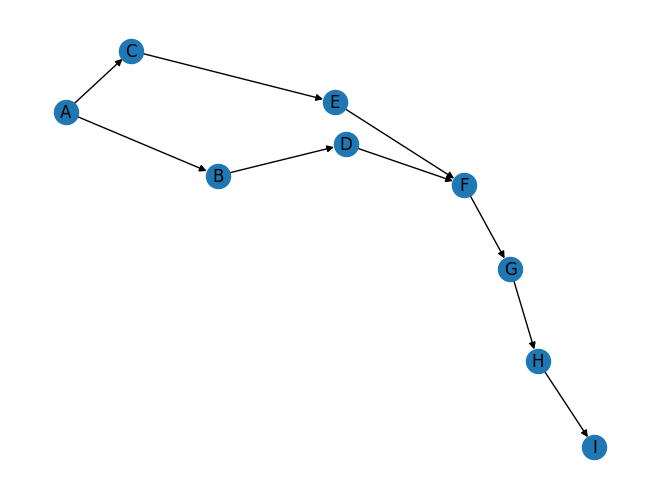

In [25]:
import networkx as nx
import matplotlib.pyplot as plt

tasks = {
    'A': {'duration': 1, 'dependencies': []},
    'B': {'duration': 3, 'dependencies': ['A']},
    'C': {'duration': 2, 'dependencies': ['A']},
    'D': {'duration': 6, 'dependencies': ['B']},
    'E': {'duration': 4, 'dependencies': ['C']},
    'F': {'duration': 3, 'dependencies': ['D', 'E']},
    'G': {'duration': 2, 'dependencies': ['F']},
    'H': {'duration': 5, 'dependencies': ['G']},
    'I': {'duration': 3, 'dependencies': ['H']}
}

G = nx.DiGraph()
for t, d in tasks.items():
    G.add_node(t, duration=d['duration'])
    for dep in d['dependencies']:
        G.add_edge(dep, t)

order = list(nx.topological_sort(G))
ES, EF = {t: 0 for t in order}, {t: 0 for t in order}

for t in order:
    EF[t] = ES[t] + G.nodes[t]['duration']
    for s in G.successors(t):
        ES[s] = max(ES[s], EF[t])

LS, LF = ES.copy(), EF.copy()

for t in reversed(order):
    for p in G.predecessors(t):
        LF[p] = min(LF[p], LS[t])
        LS[p] = LF[p] - G.nodes[p]['duration']

CP = [t for t in order if ES[t] == LS[t]]

print("Critical Path:", CP)
nx.draw(G, nx.spring_layout(G), with_labels=True)
plt.show()

EXPERIMENT 5

Critical Path: ['A', 'B', 'C', 'D', 'E', 'F', 'G', 'H', 'I']


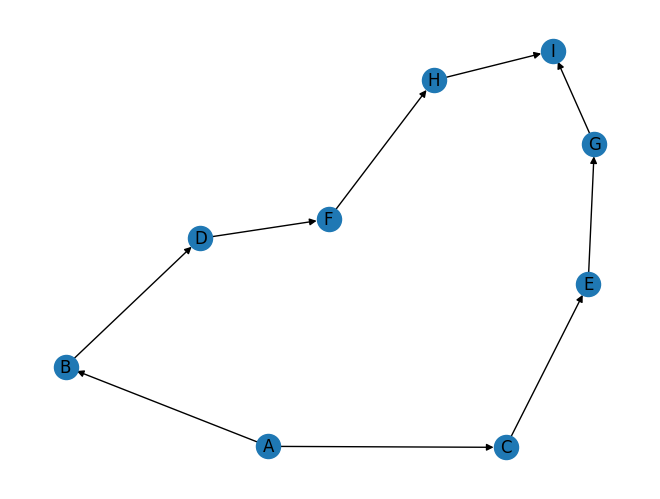

In [26]:
import networkx as nx
import matplotlib.pyplot as plt

tasks = {
    'A': {'duration': 3, 'dependencies': []},
    'B': {'duration': 2, 'dependencies': ['A']},
    'C': {'duration': 5, 'dependencies': ['A']},
    'D': {'duration': 4, 'dependencies': ['B']},
    'E': {'duration': 3, 'dependencies': ['C']},
    'F': {'duration': 2, 'dependencies': ['D']},
    'G': {'duration': 6, 'dependencies': ['E']},
    'H': {'duration': 3, 'dependencies': ['F']},
    'I': {'duration': 4, 'dependencies': ['G', 'H']}
}

G = nx.DiGraph()
for t, d in tasks.items():
    G.add_node(t, duration=d['duration'])
    for dep in d['dependencies']:
        G.add_edge(dep, t)

order = list(nx.topological_sort(G))
ES, EF = {t: 0 for t in order}, {t: 0 for t in order}

for t in order:
    EF[t] = ES[t] + G.nodes[t]['duration']
    for s in G.successors(t):
        ES[s] = max(ES[s], EF[t])

LS, LF = ES.copy(), EF.copy()

for t in reversed(order):
    for p in G.predecessors(t):
        LF[p] = min(LF[p], LS[t])
        LS[p] = LF[p] - G.nodes[p]['duration']

CP = [t for t in order if ES[t] == LS[t]]

print("Critical Path:", CP)
nx.draw(G, nx.spring_layout(G), with_labels=True)
plt.show()

EXPERIMENT 6

Critical Path: ['A', 'B', 'C', 'D', 'E', 'F', 'G', 'H', 'I']


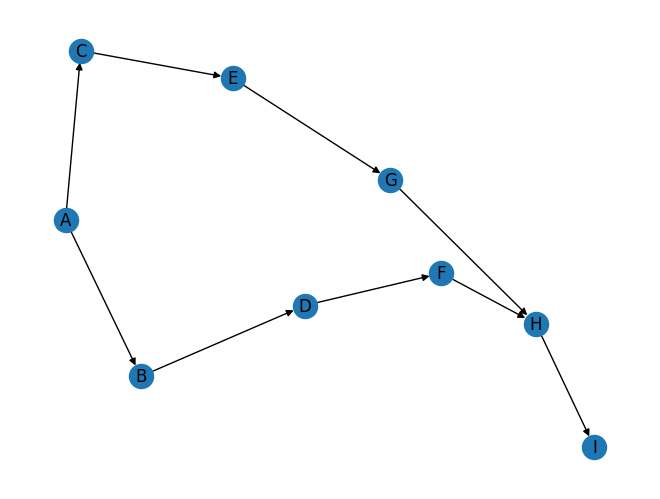

In [27]:
import networkx as nx
import matplotlib.pyplot as plt

tasks = {
    'A': {'duration': 2, 'dependencies': []},
    'B': {'duration': 4, 'dependencies': ['A']},
    'C': {'duration': 3, 'dependencies': ['A']},
    'D': {'duration': 5, 'dependencies': ['B']},
    'E': {'duration': 2, 'dependencies': ['C']},
    'F': {'duration': 4, 'dependencies': ['D']},
    'G': {'duration': 3, 'dependencies': ['E']},
    'H': {'duration': 2, 'dependencies': ['F', 'G']},
    'I': {'duration': 5, 'dependencies': ['H']}
}

G = nx.DiGraph()
for t, d in tasks.items():
    G.add_node(t, duration=d['duration'])
    for dep in d['dependencies']:
        G.add_edge(dep, t)

order = list(nx.topological_sort(G))
ES, EF = {t: 0 for t in order}, {t: 0 for t in order}

for t in order:
    EF[t] = ES[t] + G.nodes[t]['duration']
    for s in G.successors(t):
        ES[s] = max(ES[s], EF[t])

LS, LF = ES.copy(), EF.copy()

for t in reversed(order):
    for p in G.predecessors(t):
        LF[p] = min(LF[p], LS[t])
        LS[p] = LF[p] - G.nodes[p]['duration']

CP = [t for t in order if ES[t] == LS[t]]

print("Critical Path:", CP)
nx.draw(G, nx.spring_layout(G), with_labels=True)
plt.show()

EXPERIMENT 7

Critical Path: ['A', 'B', 'C', 'D', 'E', 'F', 'G', 'H', 'I']


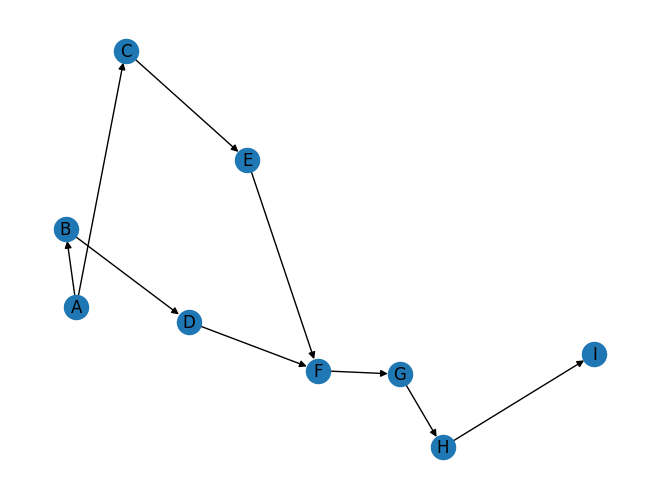

In [28]:
import networkx as nx
import matplotlib.pyplot as plt

tasks = {
    'A': {'duration': 1, 'dependencies': []},
    'B': {'duration': 3, 'dependencies': ['A']},
    'C': {'duration': 2, 'dependencies': ['A']},
    'D': {'duration': 6, 'dependencies': ['B']},
    'E': {'duration': 4, 'dependencies': ['C']},
    'F': {'duration': 3, 'dependencies': ['D', 'E']},
    'G': {'duration': 2, 'dependencies': ['F']},
    'H': {'duration': 5, 'dependencies': ['G']},
    'I': {'duration': 3, 'dependencies': ['H']}
}

G = nx.DiGraph()
for t, d in tasks.items():
    G.add_node(t, duration=d['duration'])
    for dep in d['dependencies']:
        G.add_edge(dep, t)

order = list(nx.topological_sort(G))
ES, EF = {t: 0 for t in order}, {t: 0 for t in order}

for t in order:
    EF[t] = ES[t] + G.nodes[t]['duration']
    for s in G.successors(t):
        ES[s] = max(ES[s], EF[t])

LS, LF = ES.copy(), EF.copy()

for t in reversed(order):
    for p in G.predecessors(t):
        LF[p] = min(LF[p], LS[t])
        LS[p] = LF[p] - G.nodes[p]['duration']

CP = [t for t in order if ES[t] == LS[t]]

print("Critical Path:", CP)
nx.draw(G, nx.spring_layout(G), with_labels=True)
plt.show()

EXPERIMENT 8

Critical Path: ['A', 'B', 'C', 'D', 'E', 'F', 'G', 'H', 'I']


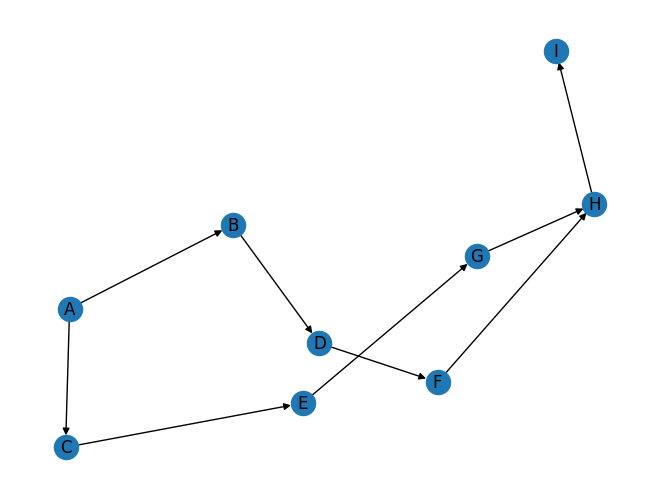

In [29]:
import networkx as nx
import matplotlib.pyplot as plt

tasks = {
    'A': {'duration': 4, 'dependencies': []},
    'B': {'duration': 3, 'dependencies': ['A']},
    'C': {'duration': 2, 'dependencies': ['A']},
    'D': {'duration': 5, 'dependencies': ['B']},
    'E': {'duration': 6, 'dependencies': ['C']},
    'F': {'duration': 2, 'dependencies': ['D']},
    'G': {'duration': 3, 'dependencies': ['E']},
    'H': {'duration': 4, 'dependencies': ['F', 'G']},
    'I': {'duration': 1, 'dependencies': ['H']}
}

G = nx.DiGraph()
for t, d in tasks.items():
    G.add_node(t, duration=d['duration'])
    for dep in d['dependencies']:
        G.add_edge(dep, t)

order = list(nx.topological_sort(G))
ES, EF = {t: 0 for t in order}, {t: 0 for t in order}

for t in order:
    EF[t] = ES[t] + G.nodes[t]['duration']
    for s in G.successors(t):
        ES[s] = max(ES[s], EF[t])

LS, LF = ES.copy(), EF.copy()

for t in reversed(order):
    for p in G.predecessors(t):
        LF[p] = min(LF[p], LS[t])
        LS[p] = LF[p] - G.nodes[p]['duration']

CP = [t for t in order if ES[t] == LS[t]]

print("Critical Path:", CP)
nx.draw(G, nx.spring_layout(G), with_labels=True)
plt.show()